# 1. Prepare the environment

In [1]:
# List all NVIDIA GPUs as available in this computer (or Colab's session)
!nvidia-smi -L

GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-e2aa63f1-7ef5-0736-ac9f-f0ac987de597)


In [2]:
import sys
print( f"Python {sys.version}\n" )

import numpy as np
print( f"NumPy {np.__version__}\n" )

import matplotlib.pyplot as plt
%matplotlib inline

# https://keras.io/getting_started/
# The backend must be configured before importing Keras, and the backend cannot be changed after the package has been imported.
import os
os.environ["KERAS_BACKEND"] = "torch"  # "jax", "tensorflow"

import keras
print(f"Keras {keras.__version__}")
print(f"|- Keras backend = {keras.backend.backend()}")
print(f"|- Keras backend image data format = {keras.backend.image_data_format()}\n")

import torch
print( f"PyTorch {torch.__version__}" )

# Get all available accelerators such as CUDA, MPS, MTIA, or XPU
num_accelerators = torch.accelerator.device_count()

if (num_accelerators <= 0):
    print("|- No hardware accelerators found. Using CPU only.")
else:
    print(f"|- PyTorch detected {num_accelerators} hardware accelerator(s)")
    print(f"|- PyTorch detected '{torch.accelerator.current_accelerator().type.upper()}' as the current accelerator")

    # Check cuda availability
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"|- PyTorch detected {num_gpus} CUDA GPU(s):")
    for i in range(num_gpus):
        print(f"   |- CUDA GPU {i}: {torch.cuda.get_device_name(i)}")

Python 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]

NumPy 2.0.2

Keras 3.10.0
|- Keras backend = torch
|- Keras backend image data format = channels_last

PyTorch 2.8.0+cu126
|- PyTorch detected 1 hardware accelerator(s)
|- PyTorch detected 'CUDA' as the current accelerator
|- PyTorch detected 1 CUDA GPU(s):
   |- CUDA GPU 0: NVIDIA A100-SXM4-40GB


# 2. Load the pre-trained model

In [4]:
# Load the ImageNet VGG-16 model, including both the feature extractor part and the classifier part
# By default, VGG-16 is designed for an input image of dimension 224x224x3
vgg = keras.applications.VGG16(weights="imagenet", include_top=True)

vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

# 3. Use the pre-trained model

In [5]:
# Load a test image from Internet
!wget "https://www.dogbreedinfo.com/images21/Pomeranianommania%20PoetryInMotionandPommaniaMsDynamite.jpg"

--2025-09-04 11:27:03--  https://www.dogbreedinfo.com/images21/Pomeranianommania%20PoetryInMotionandPommaniaMsDynamite.jpg
Resolving www.dogbreedinfo.com (www.dogbreedinfo.com)... 192.124.249.54
Connecting to www.dogbreedinfo.com (www.dogbreedinfo.com)|192.124.249.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50309 (49K) [image/jpeg]
Saving to: ‘Pomeranianommania PoetryInMotionandPommaniaMsDynamite.jpg’

Pomeranianommania P 100%[===================>]  49.13K  --.-KB/s    in 0.02s   

2025-09-04 11:27:03 (2.86 MB/s) - ‘Pomeranianommania PoetryInMotionandPommaniaMsDynamite.jpg’ saved [50309/50309]



In [6]:
!ls

'Pomeranianommania PoetryInMotionandPommaniaMsDynamite.jpg'   sample_data


type(img) = <class 'PIL.Image.Image'>
type(x) = <class 'numpy.ndarray'> , x.dtype = float32 , x.shape = (224, 224, 3) , min(x) = 0.0 , max(x) = 255.0


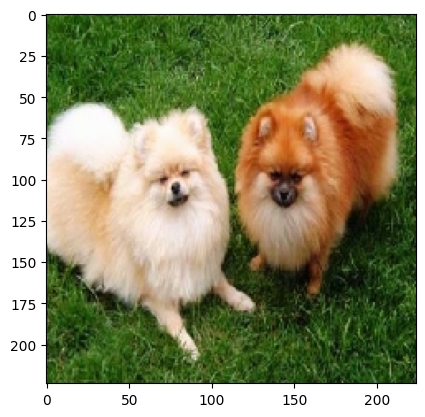

In [7]:
# Load an image as PIL.Image.Image
img_path = 'Pomeranianommania PoetryInMotionandPommaniaMsDynamite.jpg'
img =  keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
print( f"type(img) = {type(img)}" )

# Convert PIL Image to NumPy ndarray
x = keras.preprocessing.image.img_to_array(img)
print( f"type(x) = {type(x)} , x.dtype = {x.dtype} , x.shape = {x.shape} , min(x) = {np.min(x)} , max(x) = {np.max(x)}" )

# Display the NumPy image
plt.imshow( x.astype(np.uint8) )
plt.show()

In [8]:
# Preprocess the image following requirements of VGG-16
x = keras.applications.vgg16.preprocess_input(x)

print( f"type(x) = {type(x)} , x.dtype = {x.dtype} , x.shape = {x.shape} , min(x) = {np.min(x):.4f} , max(x) = {np.max(x):.4f}" )

type(x) = <class 'numpy.ndarray'> , x.dtype = float32 , x.shape = (224, 224, 3) , min(x) = -123.6800 , max(x) = 151.0610


In [9]:
# Use the model to predict this image
pred = vgg.predict( np.expand_dims(x, axis=0) )

# Decode the top 10 classes
predictions = keras.applications.vgg16.decode_predictions(pred, top=10)[0]
for i, prediction in enumerate(predictions):
  print( f"Rank {i+1}: {prediction}" )

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 978ms/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Rank 1: ('n02112018', 'Pomeranian', np.float32(0.96605176))
Rank 2: ('n02112137', 'chow', np.float32(0.017945005))
Rank 3: ('n02112350', 'keeshond', np.float32(0.00654408))
Rank 4: ('n02086079', 'Pekinese', np.float32(0.006009293))
Rank 5: ('n02098413', 'Lhasa', np.float32(0.001018149))
Rank 6: ('n02085782', 'Japanese_spaniel', np.float32(0.0005921464))
Rank 7: ('n02097474', 'Tibetan_terrier', np.float32(0.00021959373))
Rank 8: ('n02096294', 'Australian_terrier', np.float32(0.00016783531))
Rank 9: ('n02086910', 'papillon', np.float32(0.00014480579))
Rank 10: ('n02094433', 'Yorkshire_terrier', np.float32(0.00012097858))
